In [2]:
from scipy.io import wavfile
import numpy as np
from scipy import signal
from scipy.signal import kaiser_beta
from pystoi.stoi import stoi
import pandas as pd
import matplotlib.pyplot as plt
import os
import subprocess, textwrap

ПОКАЗАТЕЛИ ВО ВРЕМЕННОЙ ОБЛАСТИ

Для временной области метрики: MSE, SNR, PSNR, корреляция аудио, STOI, PSEQ.

метрики для спектральной области: LSD, корреляция спектров, spectral entropy, spectral flatness.


================================================================
доп ф-ции

In [3]:
def _align(a, b): #возвращает две выровненные версии сигналов (чтобы сравнение было корректно)
    n = min(len(a), len(b))
    return a[:n].astype(float), b[:n].astype(float)

def resample_to(x, fs_from, fs_to):
    if fs_from == fs_to:
        return x
    g = np.gcd(fs_from, fs_to)
    return signal.resample_poly(x, fs_to // g, fs_from // g)

def align_by_xcorr(ref, test, fs, max_lag_ms = 80.0):
    # выравнивание по максимуму корреляции в пределах ±max_lag_ms
    # выравнивание сигнала для pesq метрики
    ref0 = ref - np.mean(ref)
    test0 = test - np.mean(test)

    max_lag = int(fs * max_lag_ms / 1000.0)
    c = signal.correlate(test0, ref0, mode="full")
    mid = len(c) // 2
    lo, hi = mid - max_lag, mid + max_lag + 1
    lag = np.argmax(c[lo:hi]) + lo - mid

    if lag > 0:
        test = test[lag:]
        ref = ref[:len(test)]
    elif lag < 0:
        ref = ref[-lag:]
        test = test[:len(ref)]

    n = min(len(ref), len(test))
    return ref[:n], test[:n], int(lag)

def _rfft_mag(x, fs):
    x = x.astype(float)
    win = np.hanning(len(x))
    X = np.fft.rfft(x * win)
    mag = np.abs(X) + 1e-12
    freqs = np.fft.rfftfreq(len(x), d=1.0/fs)
    return freqs, mag

===============================================
МЕТРИКИ ДЛЯ ВРЕМЕННОЙ ОБЛАСТИ:

MSE

In [4]:
def mse(a, b):
    a, b = _align(a, b)
    e = a - b
    return float(np.mean(e * e))

SNR

In [5]:
def snr_db(ref, test):
    ref, test = _align(ref, test)
    noise = ref - test
    p_sig = np.mean(ref * ref) + 1e-12
    p_noi = np.mean(noise * noise) + 1e-12
    return float(10.0 * np.log10(p_sig / p_noi))

PSNR

In [6]:
def psnr_db(ref, test, peak = 1.0):
    m = mse(ref, test) + 1e-12
    return float(10.0 * np.log10((peak * peak) / m))

Корреляция аудио

In [7]:
def corrcoef(a, b):
    a, b = _align(a, b)
    a = a - np.mean(a)
    b = b - np.mean(b)
    denom = (np.std(a) * np.std(b)) + 1e-12
    return float(np.mean(a * b) / denom)

STOI

In [8]:
def stoi_score(ref, test, fs_in, align=True):
    fs = 16000
    ref16 = resample_to(ref, fs_in, fs)
    test16 = resample_to(test, fs_in, fs)
    if align:
        ref16, test16, _ = align_by_xcorr(ref16, test16, fs)
    return float(stoi(ref16, test16, fs, extended=False))

PSEQ

In [35]:
path = "./pesq_mean.csv"

df = pd.read_csv(path)

display(df)

,dataset,count,pesq_wb_mean,pesq_wb_std,lag_samples_16k_mean
0,stft_invert_dec,23,4.641941,0.000896,0.000000
1,stft_invert_enc,23,1.038992,0.008838,54.956522
2,stft_shuffle_dec,23,4.641941,0.000896,0.000000
3,stft_shuffle_enc,23,1.278782,0.226330,151.782609


===============================================
МЕТРИКИ ДЛЯ ЧАТСОТНОЙ ОБЛАСТИ:

LSD

In [9]:
def lsd_db(ref: np.ndarray, test: np.ndarray, fs: int) -> float:
    ref, test = _align(ref, test)
    _, mag_r = _rfft_mag(ref, fs)
    _, mag_t = _rfft_mag(test, fs)
    lr = 20.0 * np.log10(mag_r)
    lt = 20.0 * np.log10(mag_t)
    return float(np.mean(np.abs(lr - lt)))

Корреляция спектров

In [ ]:
def corrcoef(a: np.ndarray, b: np.ndarray) -> float: # корреляция сигналов
    a, b = _align(a, b)
    a = a - np.mean(a)
    b = b - np.mean(b)
    denom = (np.std(a) * np.std(b)) + 1e-12
    return float(np.mean(a * b) / denom)

Spectral Entropy

In [11]:
def spectral_entropy_rfft(x: np.ndarray) -> float:
    x = x.astype(float)
    x = x - np.mean(x)

    win = np.hanning(len(x)) # окно Хэннинга длиной как сигнал, чтобы энергия не размазывалась
    X = np.fft.rfft(x * win)
    P = (np.abs(X) ** 2) + 1e-12           # энергия по частотам
    p = P / (np.sum(P) + 1e-12)            # нормировка до вероятностей

    H = -np.sum(p * np.log2(p + 1e-12))    # энтропия
    H /= np.log2(len(p))                 # нормируем в диапазон 0..1
    return float(H)

Spectral Flatness

In [12]:
def spectral_flatness(x: np.ndarray, fs: int) -> float:
    _, mag = _rfft_mag(x, fs)
    gmean = np.exp(np.mean(np.log(mag)))
    amean = np.mean(mag)
    return float(gmean / (amean + 1e-12))

main

In [26]:
def to_mono_float(data):
    if data.dtype.kind in ("i", "u"):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)

    if data.ndim > 1:
        data = data[:, 0]

    return data


def load_wav(path):
    fs, data = wavfile.read(path)
    return fs, to_mono_float(data)

Агрегация временных показателй

In [30]:
def aggregate_time_metrics(orig_path, datasets, indices):

    rows = []

    for name, path in datasets.items():

        for i in indices:

            orig_file = os.path.join(orig_path, f"test_sound{i}.wav")
            proc_file = path.format(i=i)

            row = {
                "dataset": name,
                "file": i,
                "mse": np.nan,
                "snr_db": np.nan,
                "psnr_db": np.nan,
                "corrcoef": np.nan,
                "stoi": np.nan,
                "status": "ok"
            }

            try:
                fs_o, ref = load_wav(orig_file)
                fs_p, test = load_wav(proc_file)

                if fs_p != fs_o:
                    test = resample_to(test, fs_p, fs_o)

                ref, test, _ = align_by_xcorr(ref, test, fs_o)

                row["mse"] = mse(ref, test)
                row["snr_db"] = snr_db(ref, test)
                row["psnr_db"] = psnr_db(ref, test)
                row["corrcoef"] = corrcoef(ref, test)
                row["stoi"] = stoi_score(ref, test, fs_o, align=False)

            except Exception:
                row["status"] = "fail"

            rows.append(row)

    df = pd.DataFrame(rows)

    df_mean = (
        df[df.status == "ok"]
        .groupby("dataset")
        .agg(
            mse=("mse", "mean"),
            snr_db=("snr_db", "mean"),
            psnr_db=("psnr_db", "mean"),
            corrcoef=("corrcoef", "mean"),
            stoi=("stoi", "mean"),
        )
        .reset_index()
    )

    return df, df_mean

Агрегация спектральных показателй

In [33]:
def aggregate_spectral_metrics(orig_path, datasets, indices):

    rows = []

    for name, path in datasets.items():

        for i in indices:

            orig_file = os.path.join(orig_path, f"test_sound{i}.wav")
            proc_file = path.format(i=i)

            row = {
                "dataset": name,
                "file": i,
                "lsd_db": np.nan,
                "spec_entropy_ref": np.nan,
                "spec_entropy_test": np.nan,
                "spec_entropy_diff": np.nan,
                "spec_flatness_ref": np.nan,
                "spec_flatness_test": np.nan,
                "spec_flatness_diff": np.nan,
                "status": "ok"
            }

            try:
                fs_o, ref = load_wav(orig_file)
                fs_p, test = load_wav(proc_file)

                if fs_p != fs_o:
                    test = resample_to(test, fs_p, fs_o)

                row["lsd_db"] = lsd_db(ref, test, fs_o)

                row["spec_entropy_ref"] = spectral_entropy_rfft(ref)
                row["spec_entropy_test"] = spectral_entropy_rfft(test)
                row["spec_entropy_diff"] = row["spec_entropy_test"] - row["spec_entropy_ref"]

                row["spec_flatness_ref"] = spectral_flatness(ref, fs_o)
                row["spec_flatness_test"] = spectral_flatness(test, fs_o)
                row["spec_flatness_diff"] = row["spec_flatness_test"] - row["spec_flatness_ref"]

            except Exception:
                row["status"] = "fail"

            rows.append(row)

    df = pd.DataFrame(rows)

    df_mean = (
        df[df.status == "ok"]
        .groupby("dataset")
        .agg(
            lsd_db=("lsd_db", "mean"),
            spec_entropy_ref=("spec_entropy_ref", "mean"),
            spec_entropy_test=("spec_entropy_test", "mean"),
            spec_entropy_diff=("spec_entropy_diff", "mean"),
            spec_flatness_ref=("spec_flatness_ref", "mean"),
            spec_flatness_test=("spec_flatness_test", "mean"),
            spec_flatness_diff=("spec_flatness_diff", "mean"),
        )
        .reset_index()
    )

    return df, df_mean

вызов временных показателей

In [31]:
INDICES = range(1, 24)
ORIGINAL_DATASET = "../dataset/test_sounds"

DATASETS = {
    "stft_invert_enc": "../transforms/stft/assets/encrypted/invert/test_sound{i}_invert_enc.wav",
    "stft_shuffle_enc": "../transforms/stft/assets/encrypted/shuffle/test_sound{i}_shuffle_enc.wav",

    "stft_invert_dec": "../transforms/stft/assets/decrypted/invert/test_sound{i}_invert_dec.wav",
    "stft_shuffle_dec": "../transforms/stft/assets/decrypted/shuffle/test_sound{i}_shuffle_dec.wav",
}

df_time, df_time_mean = aggregate_time_metrics(
    ORIGINAL_DATASET,
    DATASETS,
    INDICES
)

display(df_time_mean)

,dataset,mse,snr_db,psnr_db,corrcoef,stoi
0,stft_invert_dec,0.005187,-3.549053,23.713126,1.000000,1.00000
1,stft_invert_enc,0.013774,-8.399732,18.823282,0.013765,0.28825
2,stft_shuffle_dec,0.005187,-3.549053,23.713126,1.000000,1.00000
3,stft_shuffle_enc,0.001992,-0.155955,27.053910,0.011357,0.37032


вызов спектральных показателей

In [34]:
INDICES = range(1, 24)
ORIGINAL_DATASET = "../dataset/test_sounds"

DATASETS = {
    "stft_invert_enc": "../transforms/stft/assets/encrypted/invert/test_sound{i}_invert_enc.wav",
    "stft_shuffle_enc": "../transforms/stft/assets/encrypted/shuffle/test_sound{i}_shuffle_enc.wav",

    "stft_invert_dec": "../transforms/stft/assets/decrypted/invert/test_sound{i}_invert_dec.wav",
    "stft_shuffle_dec": "../transforms/stft/assets/decrypted/shuffle/test_sound{i}_shuffle_dec.wav",
}

df_spec, df_spec_mean = aggregate_spectral_metrics(
    ORIGINAL_DATASET,
    DATASETS,
    INDICES
)

display(df_spec_mean)

,dataset,lsd_db,spec_entropy_ref,spec_entropy_test,spec_entropy_diff,spec_flatness_ref,spec_flatness_test,spec_flatness_diff
0,stft_invert_dec,8.286722,0.794365,0.794366,6.052514e-07,0.21801,0.221243,0.003233
1,stft_invert_enc,24.407868,0.794365,0.791907,-2.458653e-03,0.21801,0.220821,0.002811
2,stft_shuffle_dec,8.286722,0.794365,0.794366,6.052514e-07,0.21801,0.221243,0.003233
3,stft_shuffle_enc,34.761166,0.794365,0.768686,-2.567955e-02,0.21801,0.631011,0.413001


картинки

In [32]:
def _to_float(x):
    if x.dtype.kind in ("i", "u"):
        x = x.astype(np.float64) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float64)

    if x.ndim > 1:
        x = x[:, 0]

    return x


def read_audio(path):
    fs, data = wavfile.read(path)
    return fs, _to_float(data)


def avg_spectrum_db(x, fs, nfft=65536):
    x = _to_float(x)
    win = np.hanning(len(x))
    X = np.fft.rfft(x * win, n=nfft)
    freqs = np.fft.rfftfreq(nfft, 1 / fs)
    db = 20 * np.log10(np.abs(X) + 1e-12)
    return freqs, db


def plot_avg_spectra_pairs(original_path, modified_items, nfft=65536):
    fs_orig, x_orig = read_audio(original_path)
    f_orig, d_orig = avg_spectrum_db(x_orig, fs_orig, nfft=nfft)

    for title, path in modified_items:
        fs_mod, x_mod = read_audio(path)

        if fs_mod != fs_orig:
            raise ValueError(f"sample rate mismatch: {path}")

        f_mod, d_mod = avg_spectrum_db(x_mod, fs_mod, nfft=nfft)

        plt.figure(figsize=(12, 4))
        plt.plot(f_orig, d_orig, label="original", alpha=0.85)
        plt.plot(f_mod, d_mod, label=title, alpha=0.85)
        plt.title(f"Spectrum: original vs {title}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude (dB)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_spectrogram_from_path(path, title, nperseg=1024, noverlap=768):
    fs, sig = read_audio(path)

    f, t, S = signal.spectrogram(
        sig,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        mode="magnitude"
    )

    S_db = 20 * np.log10(S + 1e-12)

    plt.figure(figsize=(12, 3.8))
    plt.pcolormesh(t, f, S_db, shading="auto")
    plt.title(title)
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.colorbar(label="dB")
    plt.ylim(0, fs / 2)
    plt.tight_layout()
    plt.show()


def plot_all_spectrograms(original_path, modified_items, nperseg=1024, noverlap=768):
    plot_spectrogram_from_path(original_path, "Original", nperseg=nperseg, noverlap=noverlap)

    for title, path in modified_items:
        plot_spectrogram_from_path(path, title, nperseg=nperseg, noverlap=noverlap)

In [35]:
original_path = "./test_sound1.wav"

modified_items = [
    ("STFT Invert Enc", "./test_sound1_invert_enc.wav"),
    ("STFT Shuffle Enc", "./test_sound1_shuffle_enc.wav"),
]

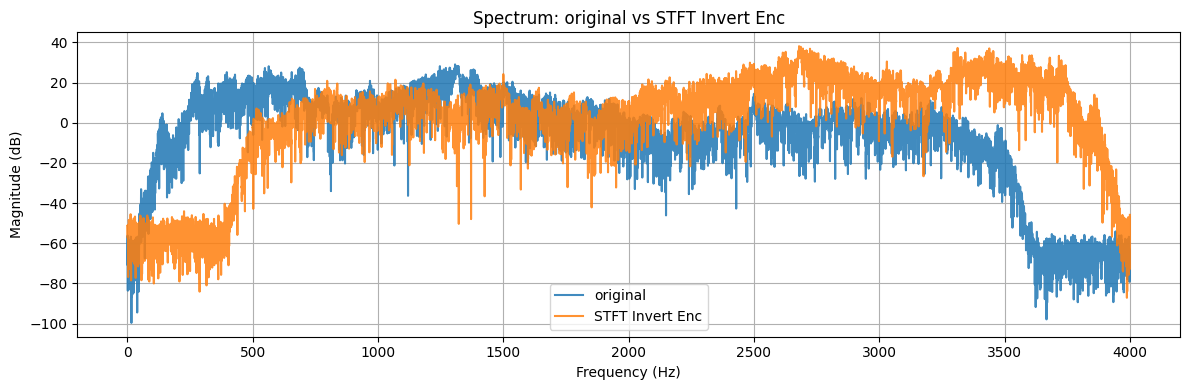

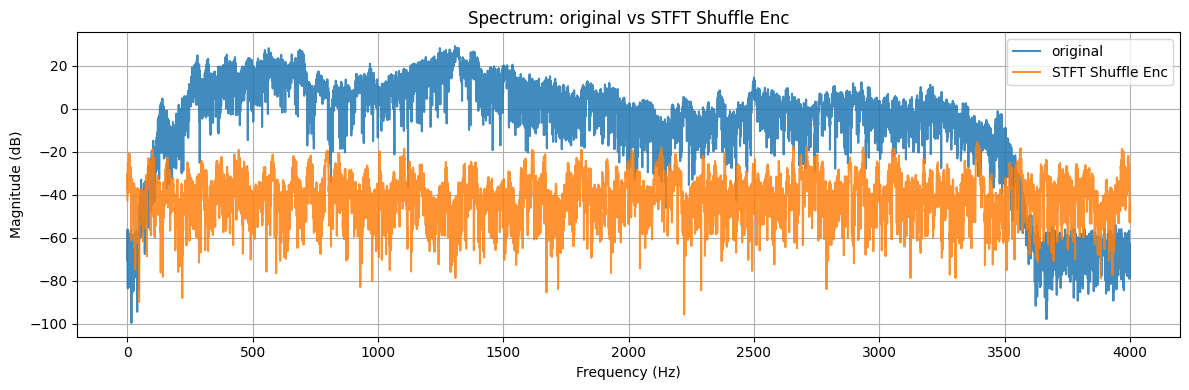

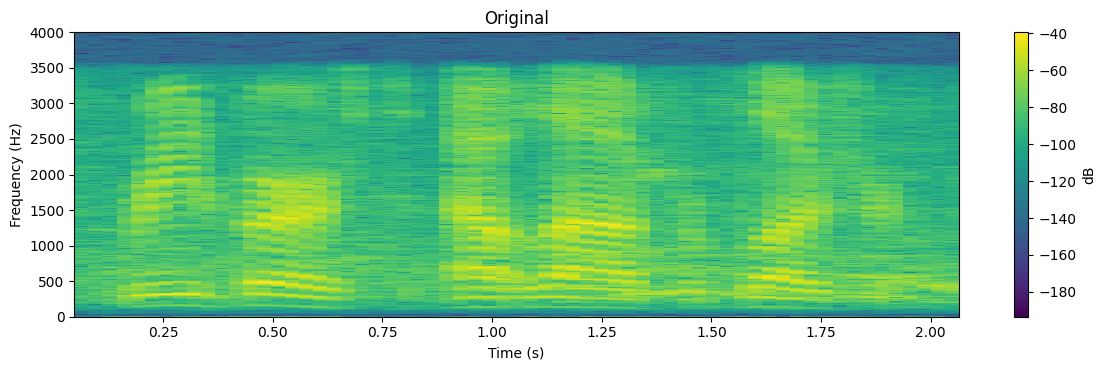

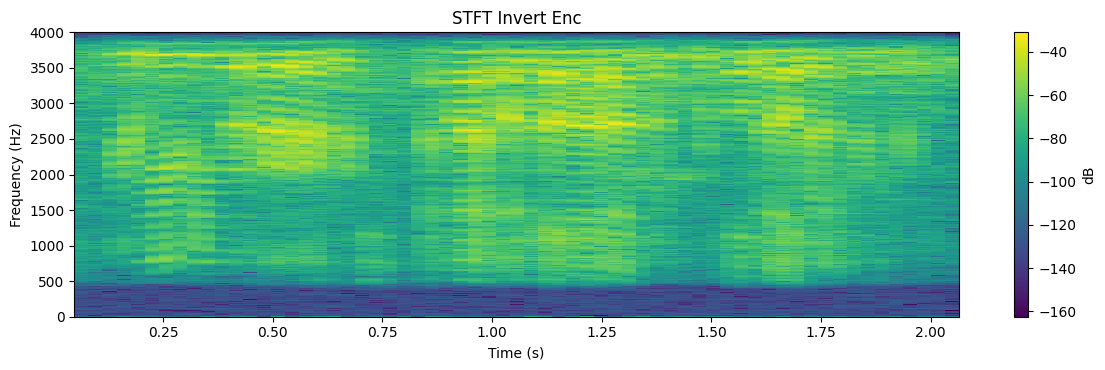

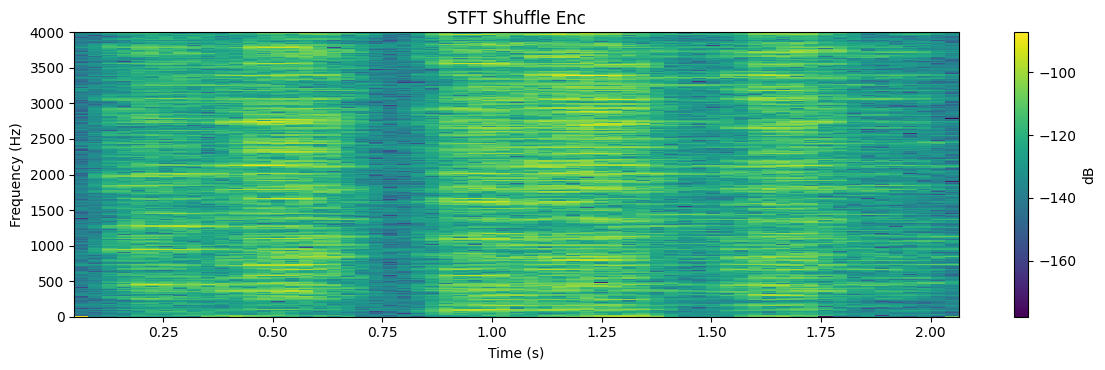

In [36]:
plot_avg_spectra_pairs(original_path, modified_items)
plot_all_spectrograms(original_path, modified_items)

======================================MAIN